# Data Structure Performance Analysis
### Cache-Hierarchy and Memory-Access Benchmarks via `perf stat`

**Methodology**: Each data structure binary was run 30 times per N via `perf stat -r 30` pinned to CPU core 0.  
**Metrics captured**: cycles, instructions, IPC, LLC cache-misses, branches  
**N sweep**: 1K → 10K → 100K → 1M → 10M

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.8,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'lines.linewidth':  2.0,
    'lines.markersize': 6,
})

# ── Colour palette — one colour per DS, grouped by category ───────────────────
DS_COLORS = {
    # Sequential / contiguous
    'Array':          '#58a6ff',
    'Vector':         '#79c0ff',
    'Deque':          '#a5d6ff',
    'Heap':           '#cae8ff',
    'CircularBuffer': '#1f6feb',
    # Linked / pointer-chasing
    'LinkedList':     '#f78166',
    'SlabList':       '#ffa198',
    # AoS / SoA
    'AoS':            '#3fb950',
    'SoA':            '#56d364',
    # Trees
    'BST':            '#ff7b72',
    'RBTree':         '#ff9e44',
    'BTree':          '#ffa657',
    'SkipList':       '#d2a8ff',
    'vEBTree':        '#bc8cff',
    # Hash / other
    'HashMap':        '#e3b341',
    'Trie':           '#f0883e',
}

CATEGORIES = {
    'Sequential': ['Array', 'Vector', 'Deque', 'Heap', 'CircularBuffer'],
    'Linked':     ['LinkedList', 'SlabList'],
    'Layout':     ['AoS', 'SoA'],
    'Trees':      ['BST', 'RBTree', 'BTree', 'SkipList', 'vEBTree'],
    'Hash/Other': ['HashMap', 'Trie'],
}

print('Setup complete.')

Setup complete.


In [2]:
# ── Data loading ──────────────────────────────────────────────────────────────
# The CSV has a 2-physical-line format per measurement:
#   Line A: ds, N, runs, cycles, instructions, ipc, cache_misses, branches
#   Line B: branch_misses, branch_misses(dup), L1_misses, TLB_misses|<not counted>
#
# We merge every pair of lines into one record.

def load_perf_csv(path):
    rows = []
    with open(path) as f:
        next(f)  # skip header
        lines = [l.strip() for l in f if l.strip()]

    i = 0
    while i < len(lines):
        a = lines[i].split(',')
        # Check if the next line is a continuation (doesn't start with a letter)
        b = lines[i+1].split(',') if (i+1 < len(lines) and not lines[i+1][0].isalpha()) else []

        def val(s):
            s = s.strip()
            if s in ('<not counted>', '', 'nan'): return np.nan
            try: return float(s)
            except: return np.nan

        row = {
            'ds':           a[0].strip(),
            'N':            val(a[1]),
            'runs':         val(a[2]),
            'cycles':       val(a[3]),
            'instructions': val(a[4]),
            'ipc':          val(a[5]),
            'cache_misses': val(a[6]),
            'branches':     val(a[7]) if len(a) > 7 else np.nan,
            'branch_misses':val(b[0]) if len(b) > 0 else np.nan,
            'L1_misses':    val(b[2]) if len(b) > 2 else np.nan,
            'TLB_misses':   val(b[3]) if len(b) > 3 else np.nan,
        }
        rows.append(row)
        i += 2 if b else 1

    df = pd.DataFrame(rows)
    df['N'] = df['N'].astype(int)

    # Derived metrics
    df['cycles_per_elem']  = df['cycles'] / df['N']
    df['cache_miss_rate']  = df['cache_misses'] / df['cycles'] * 1000   # misses per 1K cycles
    df['branch_miss_rate'] = df['branch_misses'] / df['branches'] * 100 # %
    df['L1_miss_rate']     = df['L1_misses'] / df['cycles'] * 1000
    return df

df = load_perf_csv('deep_scaling_results.csv')
print(f'Loaded {len(df)} rows, {df["ds"].nunique()} data structures')
print(f'N values: {sorted(df["N"].unique())}')
print(f'Data structures: {sorted(df["ds"].unique())}')
df.head(10)

Loaded 80 rows, 16 data structures
N values: [np.int64(1000), np.int64(10000), np.int64(100000), np.int64(1000000), np.int64(10000000)]
Data structures: ['AoS', 'Array', 'BST', 'BTree', 'CircularBuffer', 'Deque', 'HashMap', 'Heap', 'LinkedList', 'RBTree', 'SkipList', 'SlabList', 'SoA', 'Trie', 'Vector', 'vEBTree']


,ds,N,runs,cycles,instructions,ipc,cache_misses,branches,branch_misses,L1_misses,TLB_misses,cycles_per_elem,cache_miss_rate,branch_miss_rate,L1_miss_rate
0,Array,1000,30.0,3.070576e+06,3.216177e+06,1.05,58667.0,5.931740e+05,20687.0,48242.0,NaN,3070.576000,19.106187,3.487510,15.711059
1,Array,10000,30.0,4.228499e+06,4.298573e+06,1.02,37810.0,8.294880e+05,72511.0,9574.0,NaN,422.849900,8.941707,8.741658,2.264160
2,Array,100000,30.0,2.391122e+07,1.940955e+07,0.81,139355.0,3.930279e+06,620203.0,86574.0,164.0,239.112150,5.828018,15.780127,3.620644
3,Array,1000000,30.0,2.417176e+08,1.606462e+08,0.66,828648.0,3.869209e+07,7948281.0,968967.0,5760.0,241.717558,3.428166,20.542393,4.008674
4,Array,10000000,30.0,2.781144e+09,1.905089e+09,0.69,12977192.0,4.374653e+08,96205827.0,11510711.0,102433.0,278.114412,4.666134,21.991647,4.138840
5,LinkedList,1000,30.0,3.953396e+06,3.728284e+06,0.94,70893.0,6.890490e+05,16175.0,44418.0,NaN,3953.396000,17.932178,2.347438,11.235404
6,LinkedList,10000,30.0,7.247285e+06,9.314231e+06,1.29,80550.0,1.666502e+06,17528.0,241535.0,NaN,724.728500,11.114507,1.051784,33.327653
7,LinkedList,100000,30.0,4.477773e+07,5.482035e+07,1.22,827935.0,1.328779e+07,28145.0,1635730.0,2003.0,447.777340,18.489882,0.211811,36.529986
8,LinkedList,1000000,30.0,4.934052e+08,5.850986e+08,1.19,21628789.0,1.083632e+08,63095.0,16963280.0,265049.0,493.405161,43.835758,0.058226,34.380021
9,LinkedList,10000000,30.0,4.752266e+09,5.723179e+09,1.20,218714934.0,1.092317e+09,374980.0,166759821.0,2586149.0,475.226647,46.023289,0.034329,35.090587


In [3]:
# ── Summary statistics per DS ─────────────────────────────────────────────────
summary = df.groupby('ds').agg(
    min_cycles=('cycles','min'),
    max_cycles=('cycles','max'),
    mean_ipc=('ipc','mean'),
    mean_cache_miss_rate=('cache_miss_rate','mean'),
).round(2)
summary['speedup_range'] = (summary['max_cycles'] / summary['min_cycles']).round(1)
summary = summary.sort_values('max_cycles')
print('=== Summary statistics ===')
print(summary.to_string())

=== Summary statistics ===
                min_cycles    max_cycles  mean_ipc  mean_cache_miss_rate  speedup_range
ds                                                                                     
Deque            2759341.0  2.030056e+08      1.32                 14.51           73.6
Vector           2892414.0  2.178010e+08      1.16                 13.78           75.3
SlabList         2910371.0  3.478392e+08      1.12                 20.66          119.5
CircularBuffer   2666921.0  4.404302e+08      1.06                 11.50          165.1
Trie             3957900.0  5.033607e+08      2.43                  6.10          127.2
AoS              2778438.0  6.611010e+08      1.00                 22.30          237.9
SoA              2932068.0  7.098300e+08      0.92                 17.18          242.1
Heap             2909102.0  2.021030e+09      1.17                 13.02          694.7
Array            3070576.0  2.781144e+09      0.85                  8.39          905.7
vEBTr

## 1 · Cycles vs N — Full Overview (log–log)

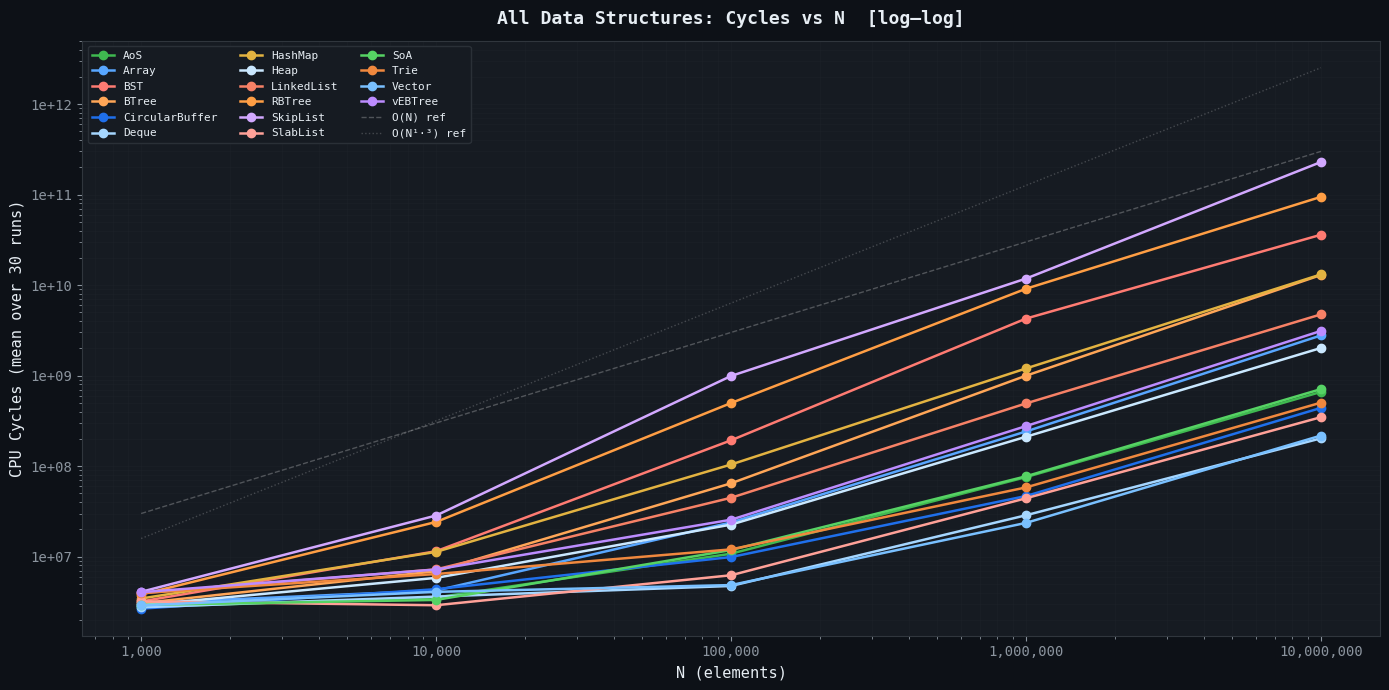

In [4]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_facecolor('#161b22')

for ds, grp in df.groupby('ds'):
    grp = grp.sort_values('N')
    color = DS_COLORS.get(ds, '#aaaaaa')
    ax.loglog(grp['N'], grp['cycles'], marker='o', color=color, label=ds, linewidth=1.8)

# Reference slopes
Ns = np.array([1e3, 1e7])
ax.loglog(Ns, 3e4 * Ns**1.0,   'w--', alpha=0.25, linewidth=1, label='O(N) ref')
ax.loglog(Ns, 2e3 * Ns**1.3,   'w:',  alpha=0.20, linewidth=1, label='O(N¹·³) ref')

ax.set_xlabel('N (elements)')
ax.set_ylabel('CPU Cycles (mean over 30 runs)')
ax.set_title('All Data Structures: Cycles vs N  [log–log]',
             fontweight='bold', pad=12)
ax.grid(True, which='both', alpha=0.3)
ax.legend(ncol=3, fontsize=8, loc='upper left')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{x:.0e}'))
plt.tight_layout()
plt.savefig('plot_01_cycles_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 2 · Cycles per Element — Cache Hierarchy Transitions

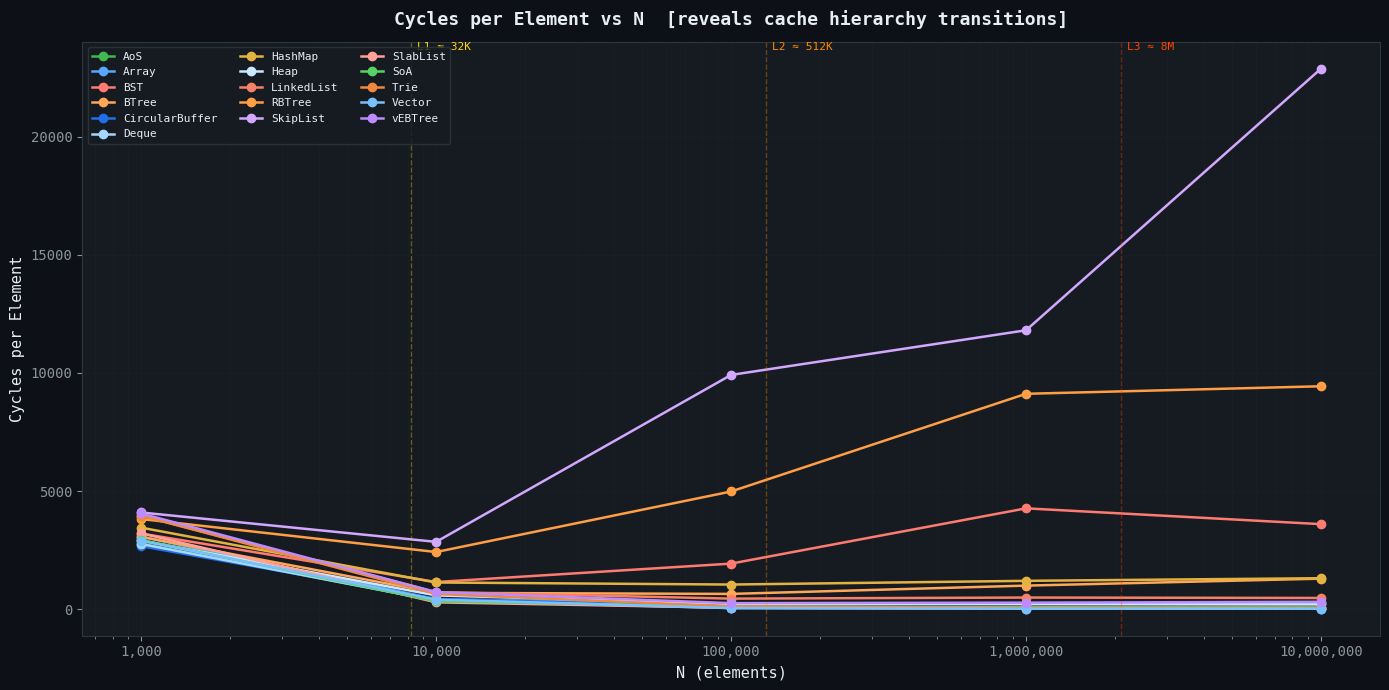

In [5]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_facecolor('#161b22')

for ds, grp in df.groupby('ds'):
    grp = grp.sort_values('N')
    color = DS_COLORS.get(ds, '#aaaaaa')
    ax.semilogx(grp['N'], grp['cycles_per_elem'], marker='o', color=color, label=ds, linewidth=1.8)

# Annotate cache hierarchy thresholds (approximate — adjust to your CPU)
for x_val, label, c in [(32_768, 'L1 ≈ 32K', '#ffd700'), (524288, 'L2 ≈ 512K', '#ff8c00'), (8_388_608, 'L3 ≈ 8M', '#ff4500')]:
    ax.axvline(x=x_val/4, color=c, alpha=0.35, linestyle='--', linewidth=1)
    ax.text(x_val/4 * 1.05, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 2000,
            label, color=c, fontsize=8, va='top')

ax.set_xlabel('N (elements)')
ax.set_ylabel('Cycles per Element')
ax.set_title('Cycles per Element vs N  [reveals cache hierarchy transitions]',
             fontweight='bold', pad=12)
ax.grid(True, which='both', alpha=0.3)
ax.legend(ncol=3, fontsize=8, loc='upper left')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('plot_02_cycles_per_elem.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 · IPC (Instructions per Cycle) — Pipeline Efficiency

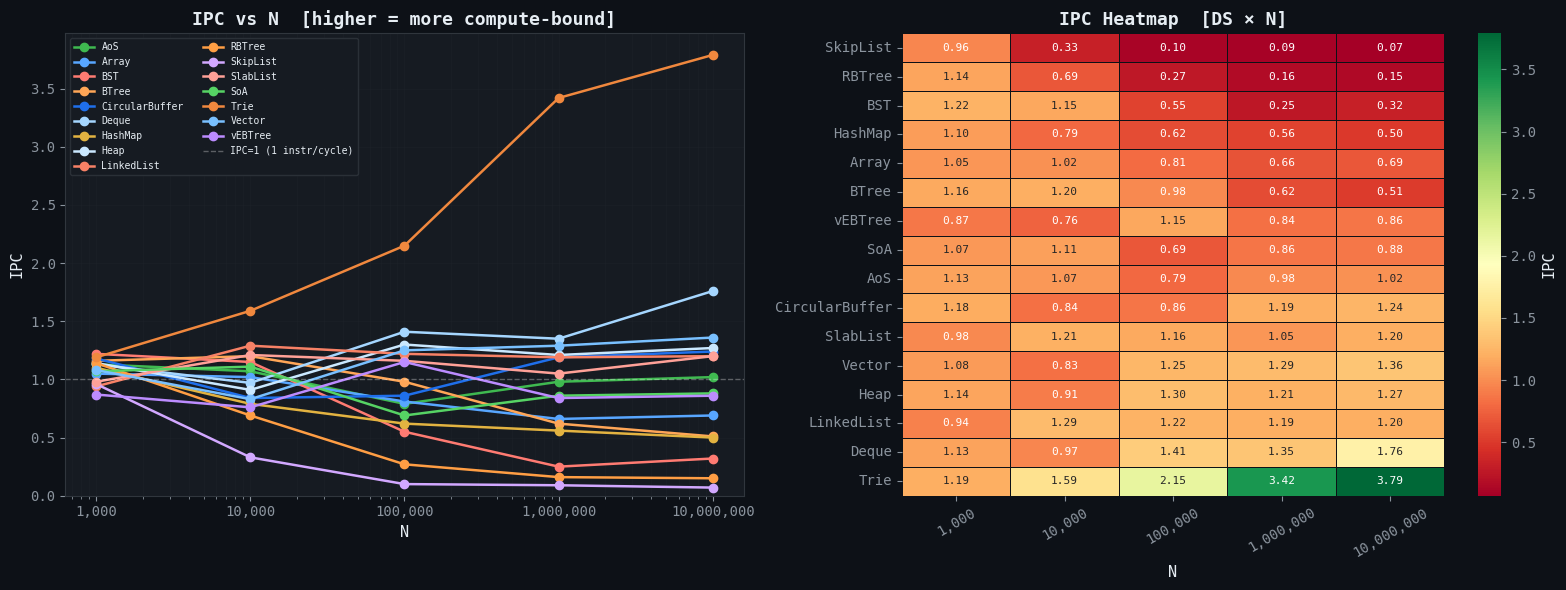

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: IPC for all DS over N
ax = axes[0]
ax.set_facecolor('#161b22')
for ds, grp in df.groupby('ds'):
    grp = grp.sort_values('N')
    color = DS_COLORS.get(ds, '#aaaaaa')
    ax.semilogx(grp['N'], grp['ipc'], marker='o', color=color, label=ds, linewidth=1.8)
ax.axhline(y=1.0, color='white', alpha=0.3, linestyle='--', linewidth=1, label='IPC=1 (1 instr/cycle)')
ax.set_xlabel('N'); ax.set_ylabel('IPC')
ax.set_title('IPC vs N  [higher = more compute-bound]', fontweight='bold')
ax.set_ylim(0, None)
ax.grid(True, which='both', alpha=0.3)
ax.legend(ncol=2, fontsize=7)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Right: IPC heatmap at N=10M
ax2 = axes[1]
pivot = df.pivot_table(index='ds', columns='N', values='ipc')
pivot = pivot.reindex(sorted(pivot.index, key=lambda d: pivot.loc[d].mean()))
sns.heatmap(pivot, ax=ax2, cmap='RdYlGn', annot=True, fmt='.2f',
            linewidths=0.5, linecolor='#0d1117',
            cbar_kws={'label': 'IPC'},
            annot_kws={'size': 8})
ax2.set_title('IPC Heatmap  [DS × N]', fontweight='bold')
ax2.set_xlabel('N')
ax2.set_ylabel('')
ax2.set_xticklabels([f'{int(float(c)):,}' for c in pivot.columns], rotation=30)
ax2.set_facecolor('#161b22')

plt.tight_layout()
plt.savefig('plot_03_ipc.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Cache Miss Analysis

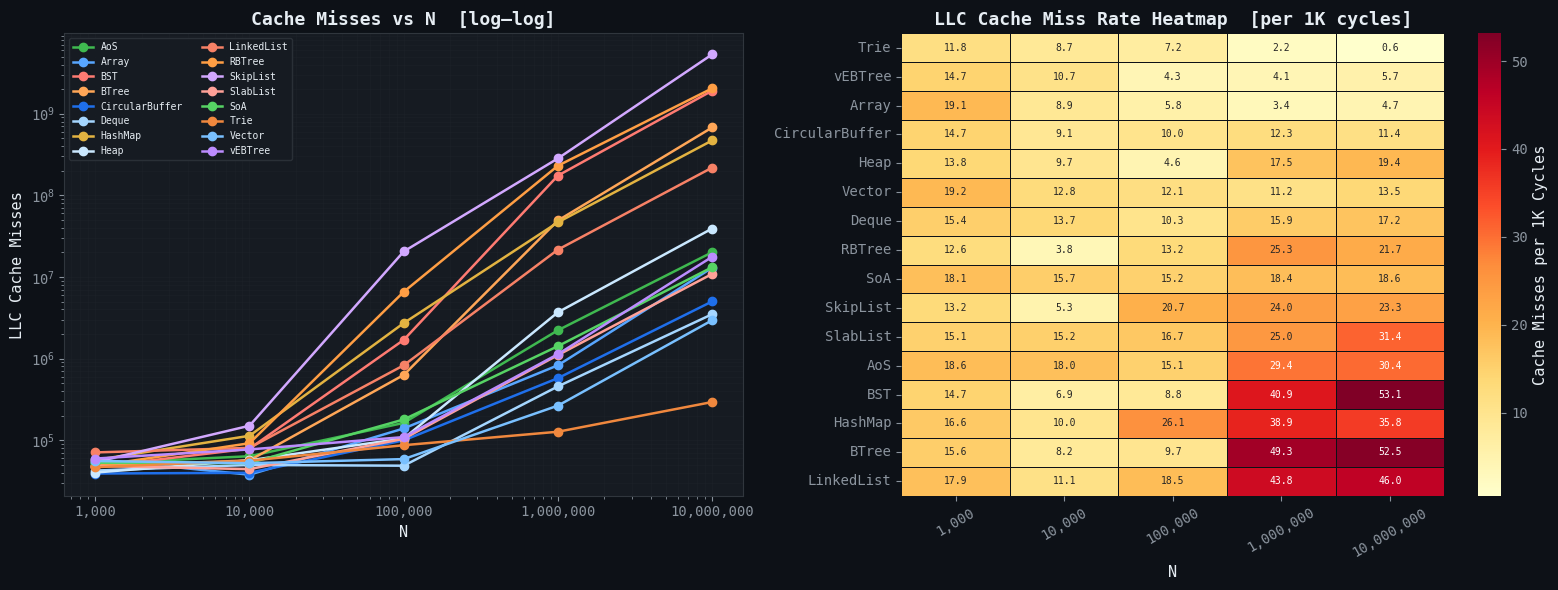

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: absolute cache misses vs N
ax = axes[0]
ax.set_facecolor('#161b22')
for ds, grp in df.groupby('ds'):
    grp = grp.sort_values('N')
    color = DS_COLORS.get(ds, '#aaaaaa')
    ax.loglog(grp['N'], grp['cache_misses'], marker='o', color=color, label=ds, linewidth=1.8)
ax.set_xlabel('N'); ax.set_ylabel('LLC Cache Misses')
ax.set_title('Cache Misses vs N  [log–log]', fontweight='bold')
ax.grid(True, which='both', alpha=0.3)
ax.legend(ncol=2, fontsize=7)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Right: cache miss rate heatmap
ax2 = axes[1]
pivot_cm = df.pivot_table(index='ds', columns='N', values='cache_miss_rate')
pivot_cm = pivot_cm.reindex(sorted(pivot_cm.index, key=lambda d: pivot_cm.loc[d].mean()))
sns.heatmap(pivot_cm, ax=ax2, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.5, linecolor='#0d1117',
            cbar_kws={'label': 'Cache Misses per 1K Cycles'},
            annot_kws={'size': 7})
ax2.set_title('LLC Cache Miss Rate Heatmap  [per 1K cycles]', fontweight='bold')
ax2.set_xlabel('N'); ax2.set_ylabel('')
ax2.set_xticklabels([f'{int(float(c)):,}' for c in pivot_cm.columns], rotation=30)
ax2.set_facecolor('#161b22')

plt.tight_layout()
plt.savefig('plot_04_cache_misses.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Category Deep-Dive: By Structural Group

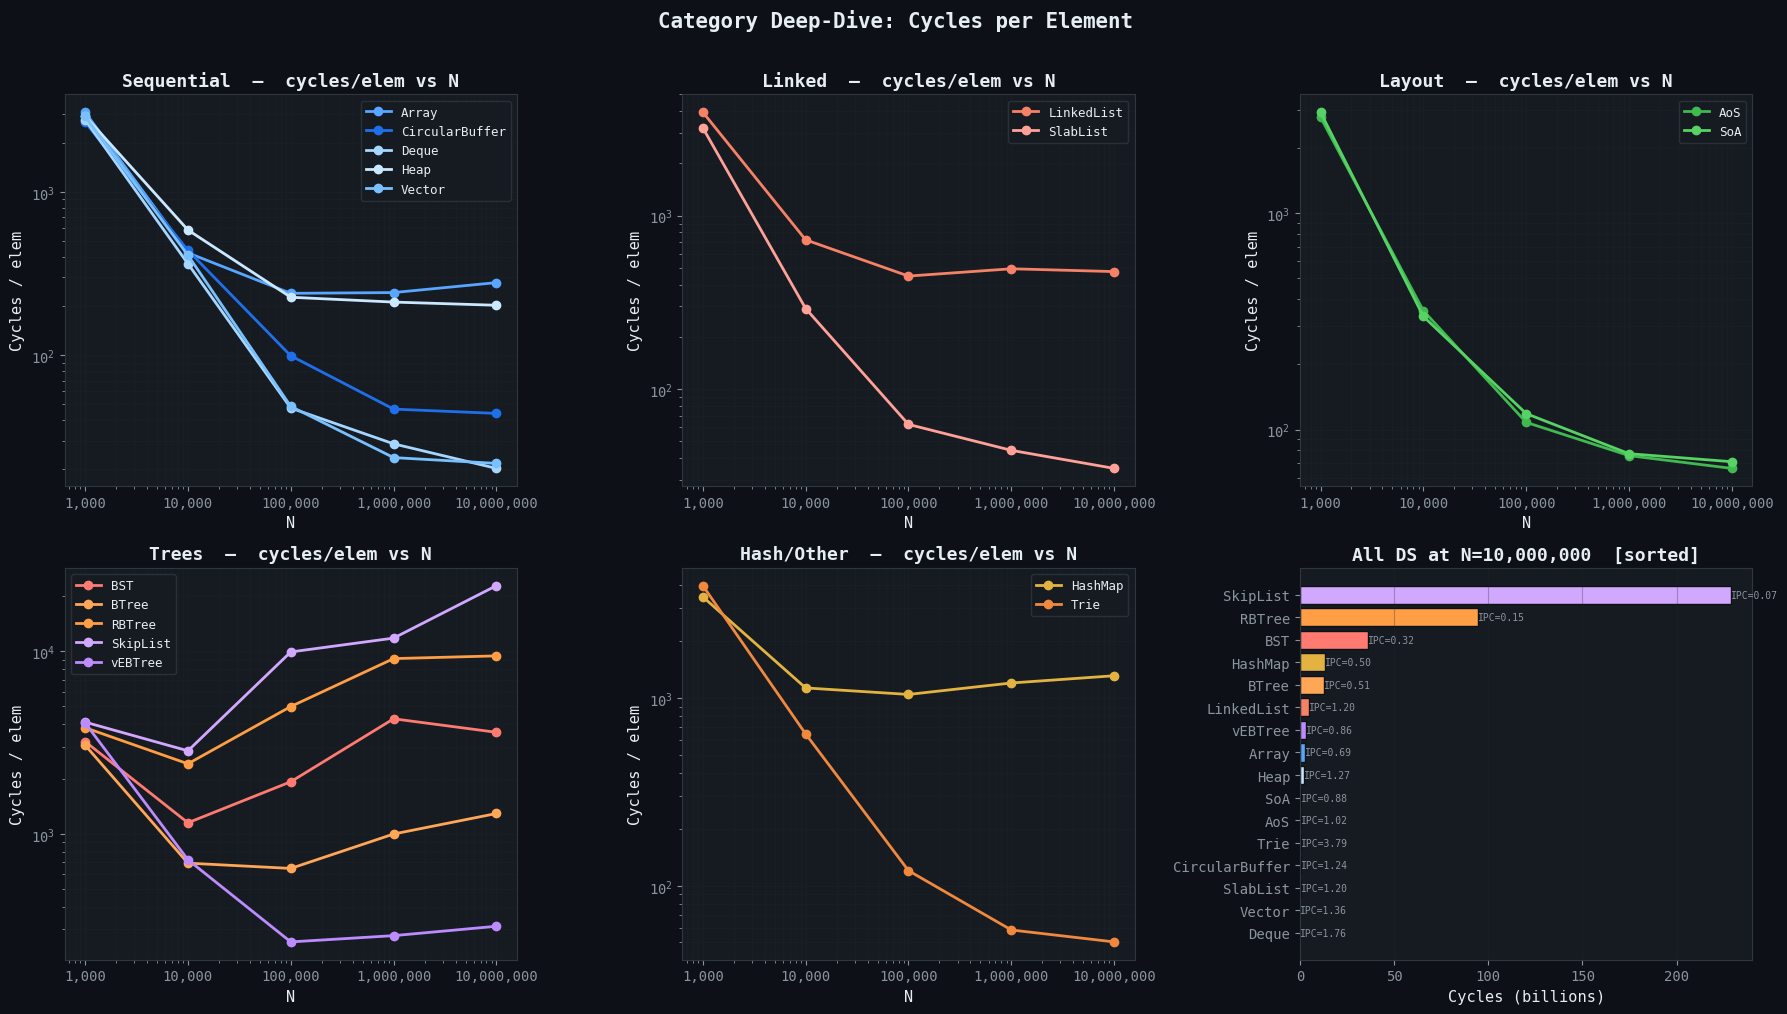

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cat_items = list(CATEGORIES.items())
# last subplot = all on one for comparison
cat_items.append(('All (N=10M)', None))

for idx, (cat_name, ds_list) in enumerate(cat_items):
    ax = axes[idx]
    ax.set_facecolor('#161b22')

    if cat_name == 'All (N=10M)':
        # Bar chart at N=10M
        n10 = df[df['N'] == df['N'].max()].sort_values('cycles')
        colors = [DS_COLORS.get(d, '#aaa') for d in n10['ds']]
        bars = ax.barh(n10['ds'], n10['cycles'] / 1e9, color=colors, edgecolor='#0d1117')
        ax.set_xlabel('Cycles (billions)')
        ax.set_title(f'All DS at N={df["N"].max():,}  [sorted]', fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        # Annotate IPC
        for bar, (_, row) in zip(bars, n10.iterrows()):
            ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                    f'IPC={row["ipc"]:.2f}', va='center', fontsize=7, color='#8b949e')
    else:
        sub = df[df['ds'].isin(ds_list)]
        for ds, grp in sub.groupby('ds'):
            grp = grp.sort_values('N')
            ax.loglog(grp['N'], grp['cycles_per_elem'], marker='o',
                      color=DS_COLORS.get(ds, '#aaa'), label=ds, linewidth=2)
        ax.set_xlabel('N'); ax.set_ylabel('Cycles / elem')
        ax.set_title(f'{cat_name}  —  cycles/elem vs N', fontweight='bold')
        ax.grid(True, which='both', alpha=0.3)
        ax.legend(fontsize=9)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('Category Deep-Dive: Cycles per Element', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_05_categories.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · AoS vs SoA — Layout Effect on Cache Bandwidth

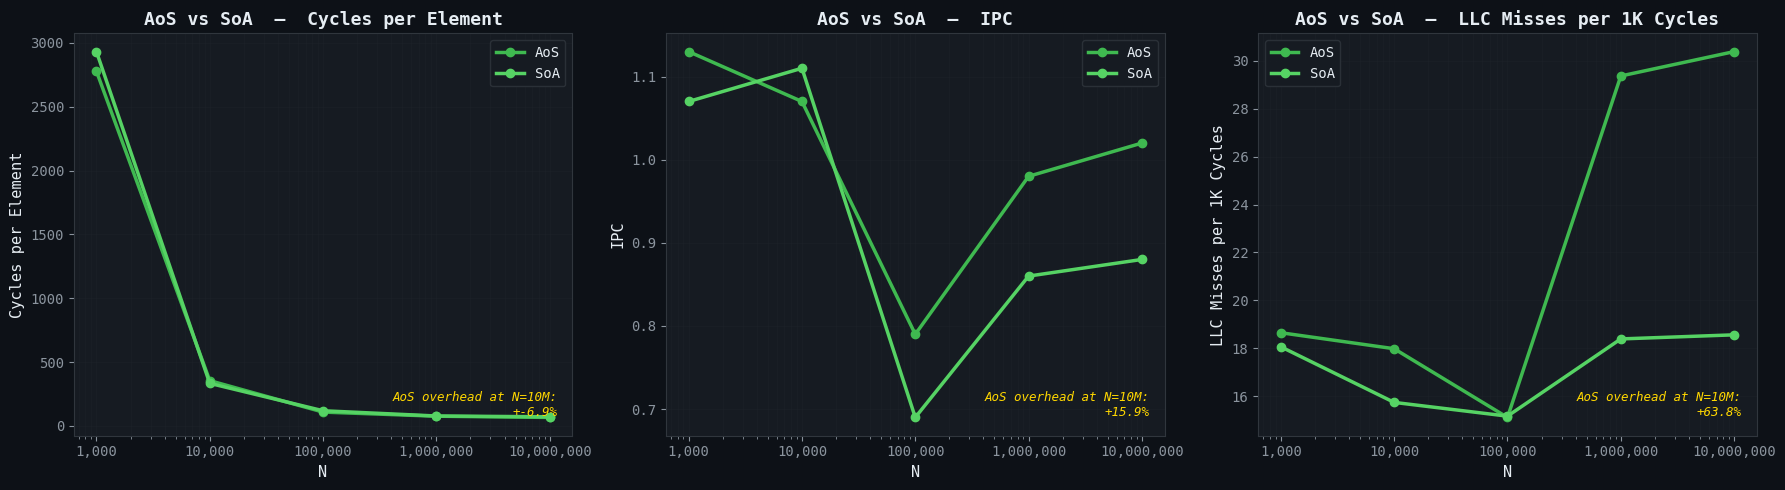

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
layout_ds = ['AoS', 'SoA']
sub = df[df['ds'].isin(layout_ds)]

metrics = [
    ('cycles_per_elem', 'Cycles per Element'),
    ('ipc',             'IPC'),
    ('cache_miss_rate', 'LLC Misses per 1K Cycles'),
]
for ax, (col, label) in zip(axes, metrics):
    ax.set_facecolor('#161b22')
    for ds, grp in sub.groupby('ds'):
        grp = grp.sort_values('N')
        ax.semilogx(grp['N'], grp[col], marker='o', color=DS_COLORS[ds], label=ds, linewidth=2.5)
    # Mark the difference at N=10M
    n_max = df['N'].max()
    vals = sub[sub['N'] == n_max].set_index('ds')[col]
    if 'AoS' in vals and 'SoA' in vals:
        diff = vals['AoS'] - vals['SoA']
        pct  = diff / vals['SoA'] * 100
        ax.text(0.97, 0.05, f'AoS overhead at N=10M:\n+{pct:.1f}%',
                transform=ax.transAxes, ha='right', fontsize=9,
                color='#ffd700', style='italic')
    ax.set_xlabel('N'); ax.set_ylabel(label)
    ax.set_title(f'AoS vs SoA  —  {label}', fontweight='bold')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=10)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('plot_06_aos_vs_soa.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Linked List vs Slab List — Allocator Locality Effect

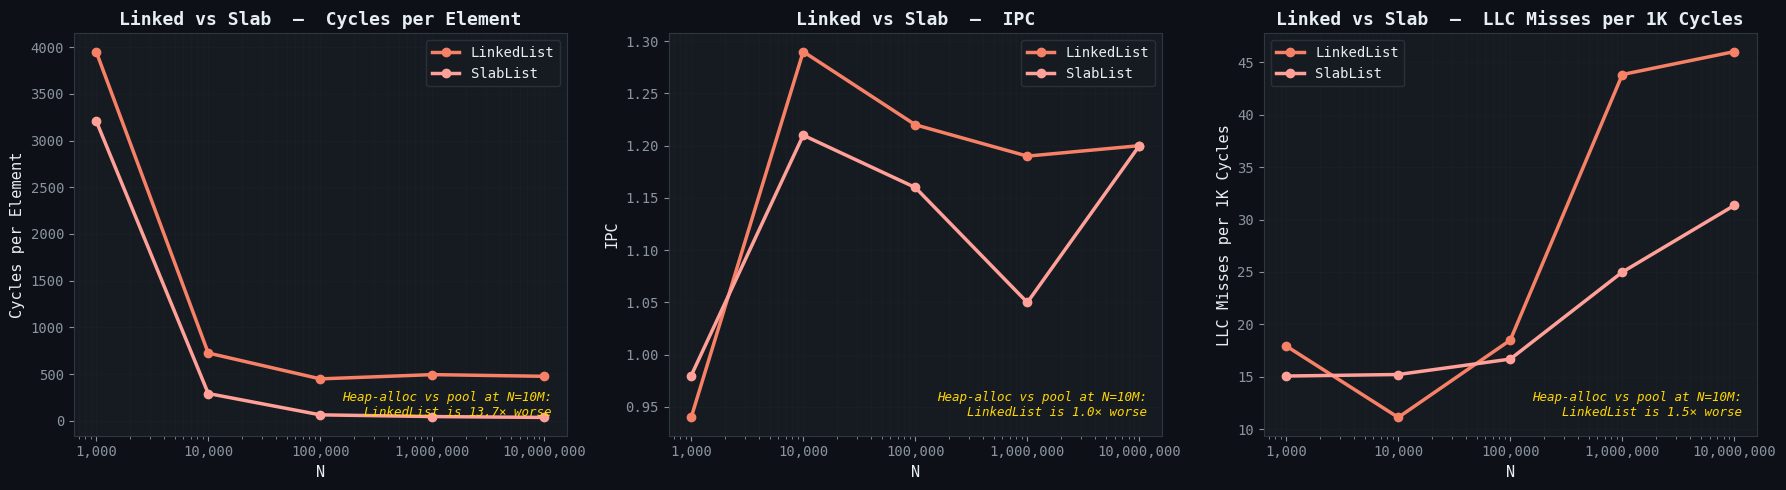

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ll_ds = ['LinkedList', 'SlabList']
sub = df[df['ds'].isin(ll_ds)]

for ax, (col, label) in zip(axes, metrics):
    ax.set_facecolor('#161b22')
    for ds, grp in sub.groupby('ds'):
        grp = grp.sort_values('N')
        ax.semilogx(grp['N'], grp[col], marker='o', color=DS_COLORS[ds], label=ds, linewidth=2.5)
    n_max = df['N'].max()
    vals = sub[sub['N'] == n_max].set_index('ds')[col]
    if 'LinkedList' in vals and 'SlabList' in vals:
        factor = vals['LinkedList'] / vals['SlabList']
        ax.text(0.97, 0.05, f'Heap-alloc vs pool at N=10M:\nLinkedList is {factor:.1f}× worse',
                transform=ax.transAxes, ha='right', fontsize=9,
                color='#ffd700', style='italic')
    ax.set_xlabel('N'); ax.set_ylabel(label)
    ax.set_title(f'Linked vs Slab  —  {label}', fontweight='bold')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=10)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('plot_07_linked_vs_slab.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 · Tree Structures: BST vs RBTree vs BTree vs SkipList vs vEBTree

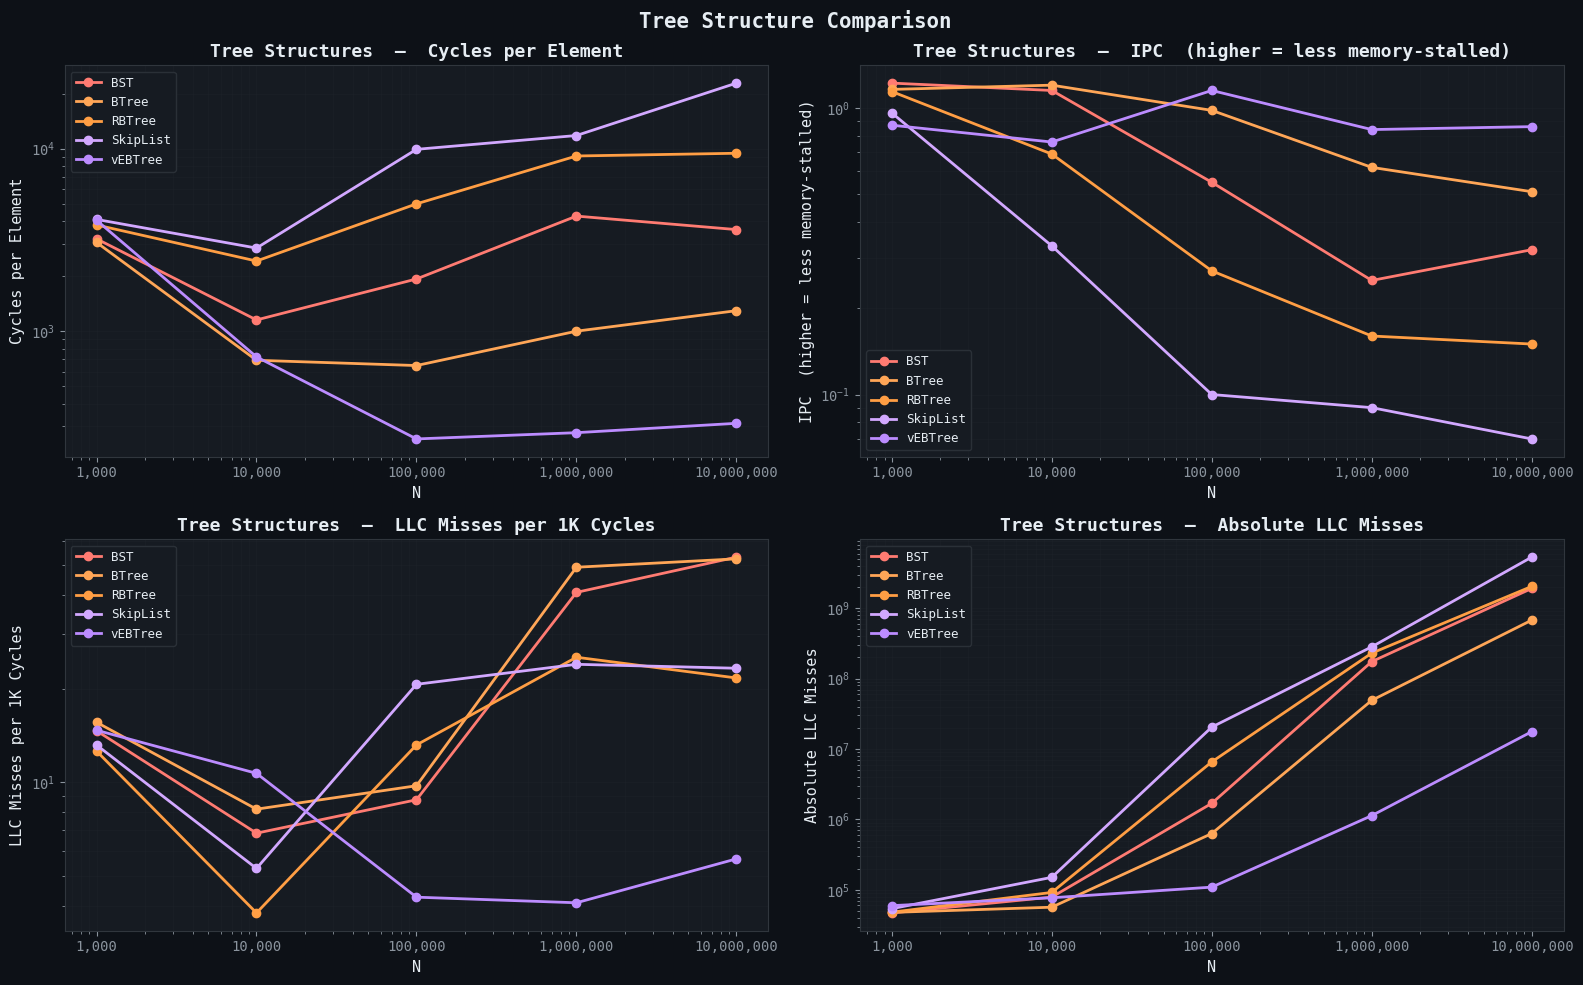

In [11]:
tree_ds = ['BST', 'RBTree', 'BTree', 'SkipList', 'vEBTree']
sub = df[df['ds'].isin(tree_ds)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

tree_metrics = [
    ('cycles_per_elem', 'Cycles per Element'),
    ('ipc',             'IPC  (higher = less memory-stalled)'),
    ('cache_miss_rate', 'LLC Misses per 1K Cycles'),
    ('cache_misses',    'Absolute LLC Misses'),
]

for ax, (col, label) in zip(axes, tree_metrics):
    ax.set_facecolor('#161b22')
    for ds, grp in sub.groupby('ds'):
        grp = grp.sort_values('N')
        ax.loglog(grp['N'], grp[col], marker='o', color=DS_COLORS[ds], label=ds, linewidth=2)
    ax.set_xlabel('N'); ax.set_ylabel(label)
    ax.set_title(f'Tree Structures  —  {label}', fontweight='bold')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('Tree Structure Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_08_trees.png', dpi=150, bbox_inches='tight')
plt.show()

## 9 · Slowdown vs Fastest — Relative Performance Ranking

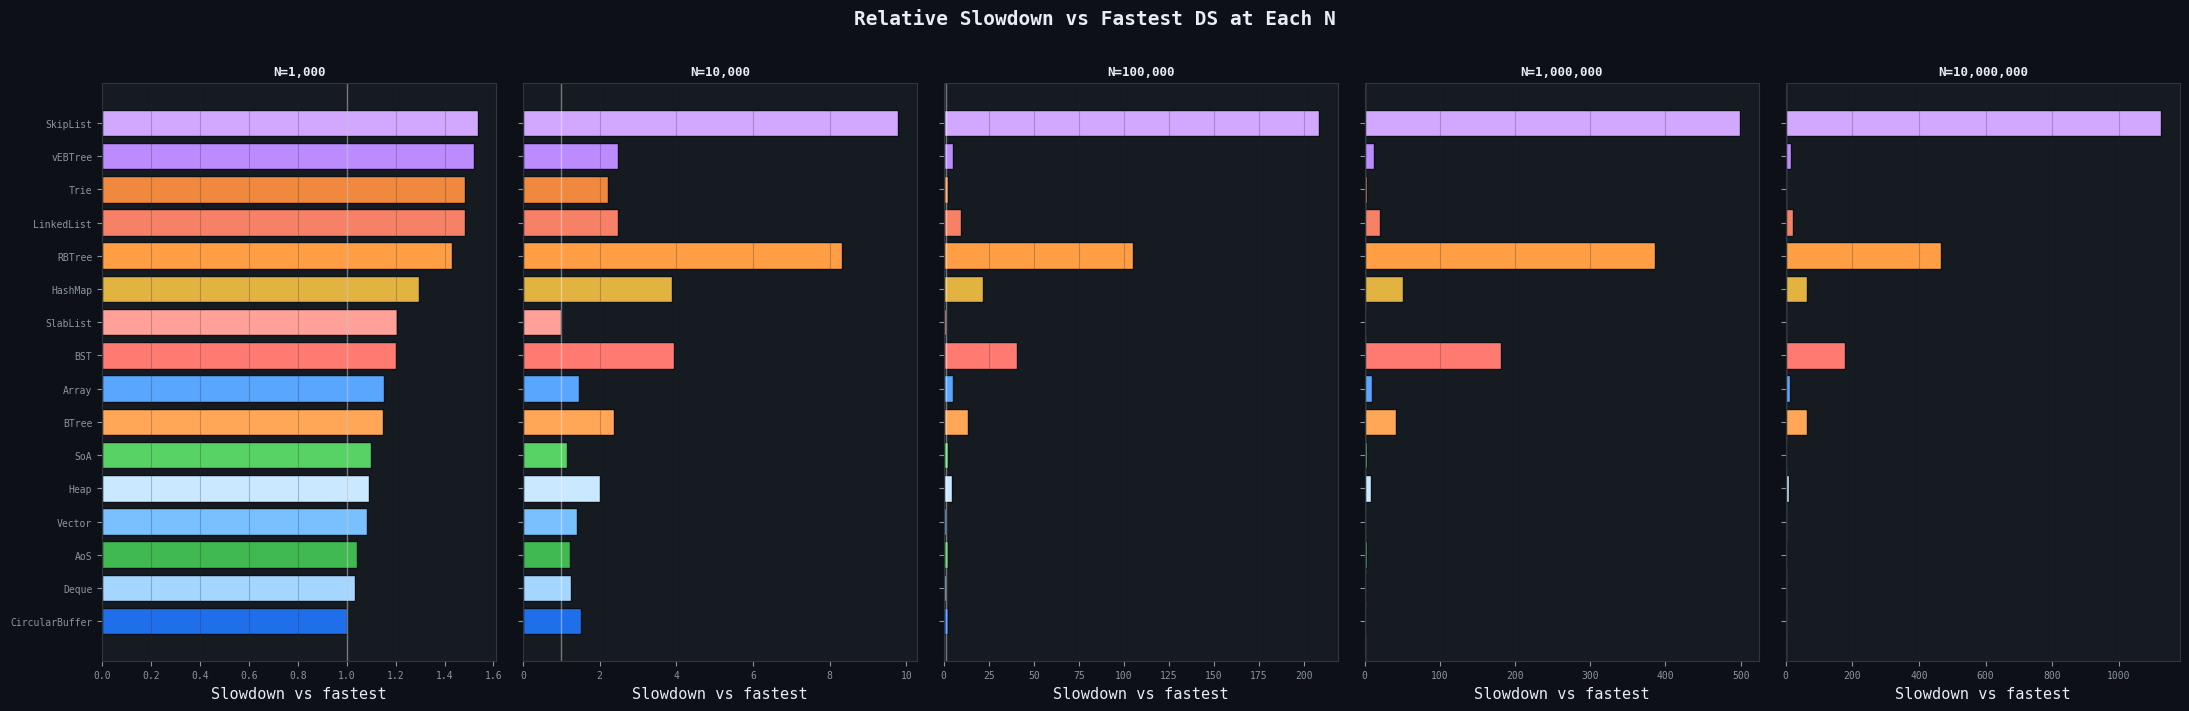

In [12]:
fig, axes = plt.subplots(1, len(df['N'].unique()), figsize=(22, 7), sharey=True)

for ax, n_val in zip(axes, sorted(df['N'].unique())):
    sub = df[df['N'] == n_val].copy()
    baseline = sub['cycles'].min()
    sub['slowdown'] = sub['cycles'] / baseline
    sub = sub.sort_values('slowdown')
    colors = [DS_COLORS.get(d, '#aaa') for d in sub['ds']]
    ax.set_facecolor('#161b22')
    bars = ax.barh(sub['ds'], sub['slowdown'], color=colors, edgecolor='#0d1117')
    ax.axvline(x=1, color='white', alpha=0.4, linewidth=1)
    ax.set_xlabel('Slowdown vs fastest')
    ax.set_title(f'N={n_val:,}', fontweight='bold', fontsize=9)
    ax.grid(axis='x', alpha=0.25)
    ax.tick_params(labelsize=7)

plt.suptitle('Relative Slowdown vs Fastest DS at Each N', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_09_slowdown_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

## 10 · Full Metric Heatmap — Correlation & Big Picture

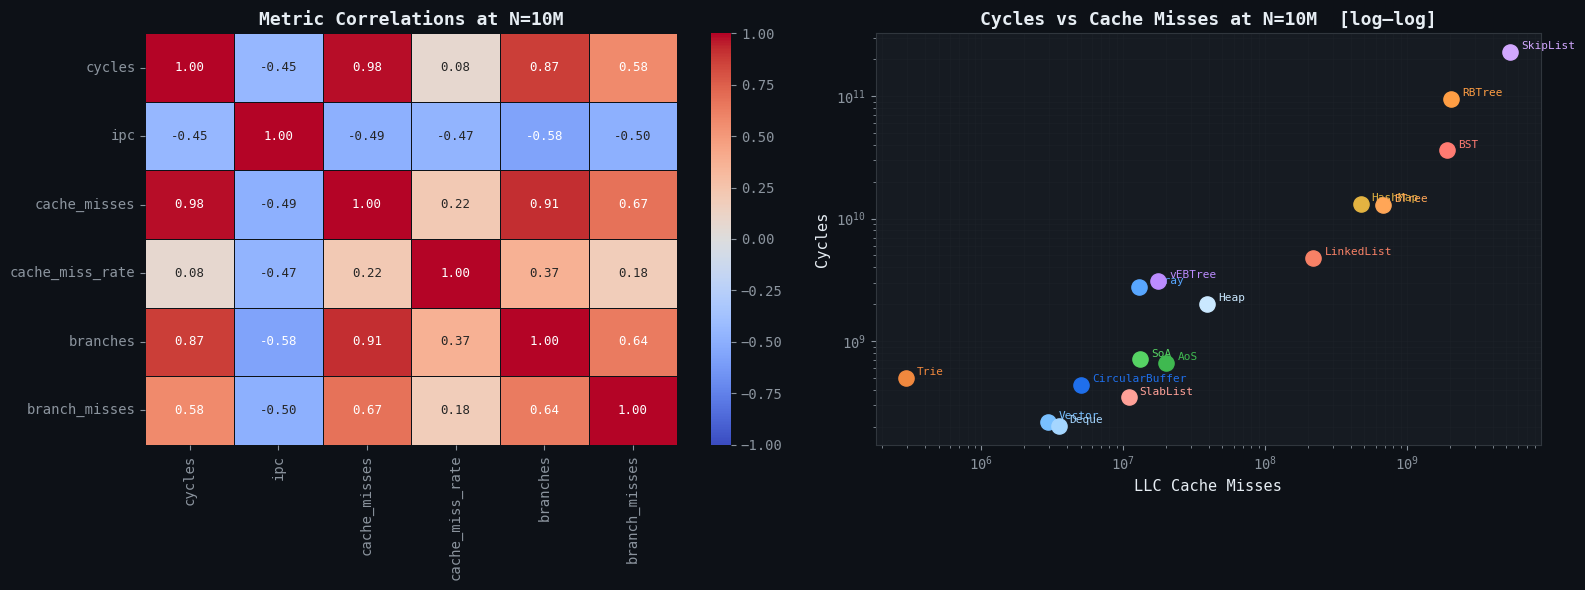

In [13]:
# Large N data for correlation
large_n = df[df['N'] == df['N'].max()][['ds','cycles','ipc','cache_misses','cache_miss_rate','branches','branch_misses']].copy()
large_n = large_n.set_index('ds').dropna(axis=1, how='all')

# Correlation matrix
corr = large_n.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: correlation heatmap
ax = axes[0]
sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            linewidths=0.5, linecolor='#0d1117', vmin=-1, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Metric Correlations at N=10M', fontweight='bold')
ax.set_facecolor('#161b22')

# Right: cycles vs cache misses scatter
ax2 = axes[1]
ax2.set_facecolor('#161b22')
for _, row in large_n.iterrows():
    ds = row.name
    ax2.scatter(row['cache_misses'], row['cycles'],
                color=DS_COLORS.get(ds, '#aaa'), s=120, zorder=5)
    ax2.annotate(ds, (row['cache_misses'], row['cycles']),
                 xytext=(8, 2), textcoords='offset points',
                 fontsize=8, color=DS_COLORS.get(ds, '#aaa'))
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('LLC Cache Misses'); ax2.set_ylabel('Cycles')
ax2.set_title('Cycles vs Cache Misses at N=10M  [log–log]', fontweight='bold')
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_10_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 11 · Growth-Rate Analysis — Scaling Exponent Estimation

=== Scaling Exponent (log-log slope of cycles vs N) ===
An exponent of 1.0 = perfectly linear; >1.0 = super-linear growth (cache effects)

AoS               exponent=0.608  R²=0.924
Array             exponent=0.767  R²=0.945
BST               exponent=1.067  R²=0.985
BTree             exponent=0.941  R²=0.971
CircularBuffer    exponent=0.546  R²=0.925
Deque             exponent=0.463  R²=0.861
HashMap           exponent=0.919  R²=0.986
Heap              exponent=0.724  R²=0.959
LinkedList        exponent=0.799  R²=0.964
RBTree            exponent=1.136  R²=0.995
SkipList          exponent=1.211  R²=0.994
SlabList          exponent=0.525  R²=0.866
SoA               exponent=0.613  R²=0.921
Trie              exponent=0.517  R²=0.913
Vector            exponent=0.452  R²=0.841
vEBTree           exponent=0.736  R²=0.943


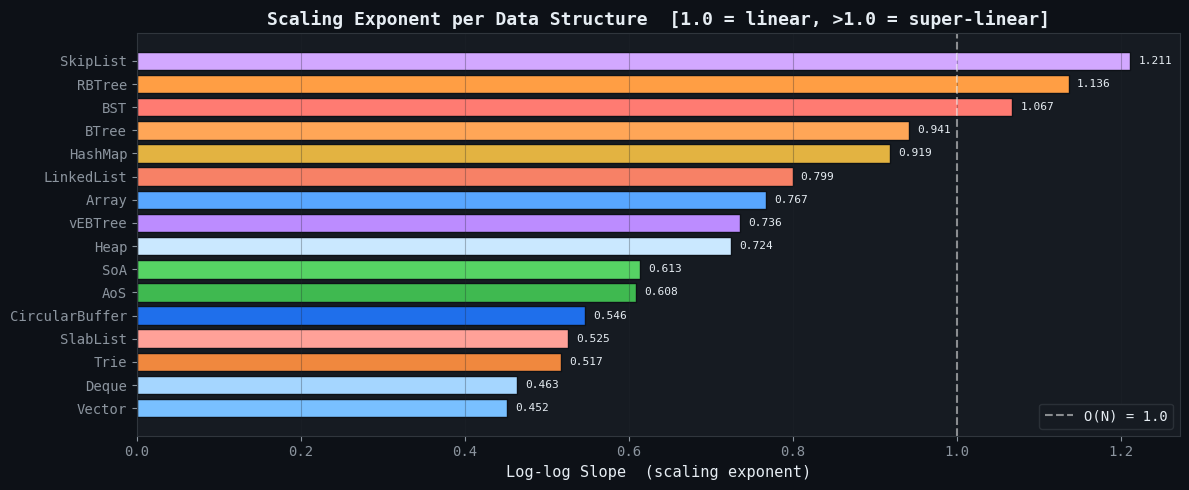

In [14]:
from scipy import stats

print('=== Scaling Exponent (log-log slope of cycles vs N) ===')
print('An exponent of 1.0 = perfectly linear; >1.0 = super-linear growth (cache effects)\n')

exponents = []
for ds, grp in df.groupby('ds'):
    grp = grp.sort_values('N').dropna(subset=['cycles'])
    if len(grp) < 3: continue
    log_n = np.log10(grp['N'])
    log_c = np.log10(grp['cycles'])
    slope, intercept, r, p, se = stats.linregress(log_n, log_c)
    exponents.append({'ds': ds, 'exponent': slope, 'R²': r**2})
    print(f'{ds:16s}  exponent={slope:.3f}  R²={r**2:.3f}')

exp_df = pd.DataFrame(exponents).sort_values('exponent')

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_facecolor('#161b22')
colors = [DS_COLORS.get(d, '#aaa') for d in exp_df['ds']]
bars = ax.barh(exp_df['ds'], exp_df['exponent'], color=colors, edgecolor='#0d1117')
ax.axvline(x=1.0, color='white', alpha=0.5, linewidth=1.5, linestyle='--', label='O(N) = 1.0')
ax.set_xlabel('Log-log Slope  (scaling exponent)')
ax.set_title('Scaling Exponent per Data Structure  [1.0 = linear, >1.0 = super-linear]', fontweight='bold')
ax.legend(); ax.grid(axis='x', alpha=0.3)
for bar, (_, row) in zip(bars, exp_df.iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{row["exponent"]:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('plot_11_exponents.png', dpi=150, bbox_inches='tight')
plt.show()

## 12 · Final Rankings Table


=== Final Rankings at N=10,000,000 (30-run mean) ===

    Data Structure           Cycles   IPC     LLC Misses      Branches LLC Miss/1K cyc
1            Deque      203,005,629  1.76      3,499,826  7.585609e+07           17.24
2           Vector      217,800,988  1.36      2,950,207  4.972103e+07           13.55
3         SlabList      347,839,179  1.20     10,905,251  7.017312e+07           31.35
4   CircularBuffer      440,430,201  1.24      5,017,802  5.876971e+07           11.39
5             Trie      503,360,669  3.79        293,761  2.625108e+08            0.58
6              AoS      661,100,953  1.02     20,091,208  1.002059e+08           30.39
7              SoA      709,829,980  0.88     13,172,693  9.122810e+07           18.56
8             Heap    2,021,029,649  1.27     39,211,293  4.001956e+08           19.40
9            Array    2,781,144,124  0.69     12,977,192  4.374653e+08            4.67
10         vEBTree    3,119,520,641  0.86     17,674,741  4.580752e+08     

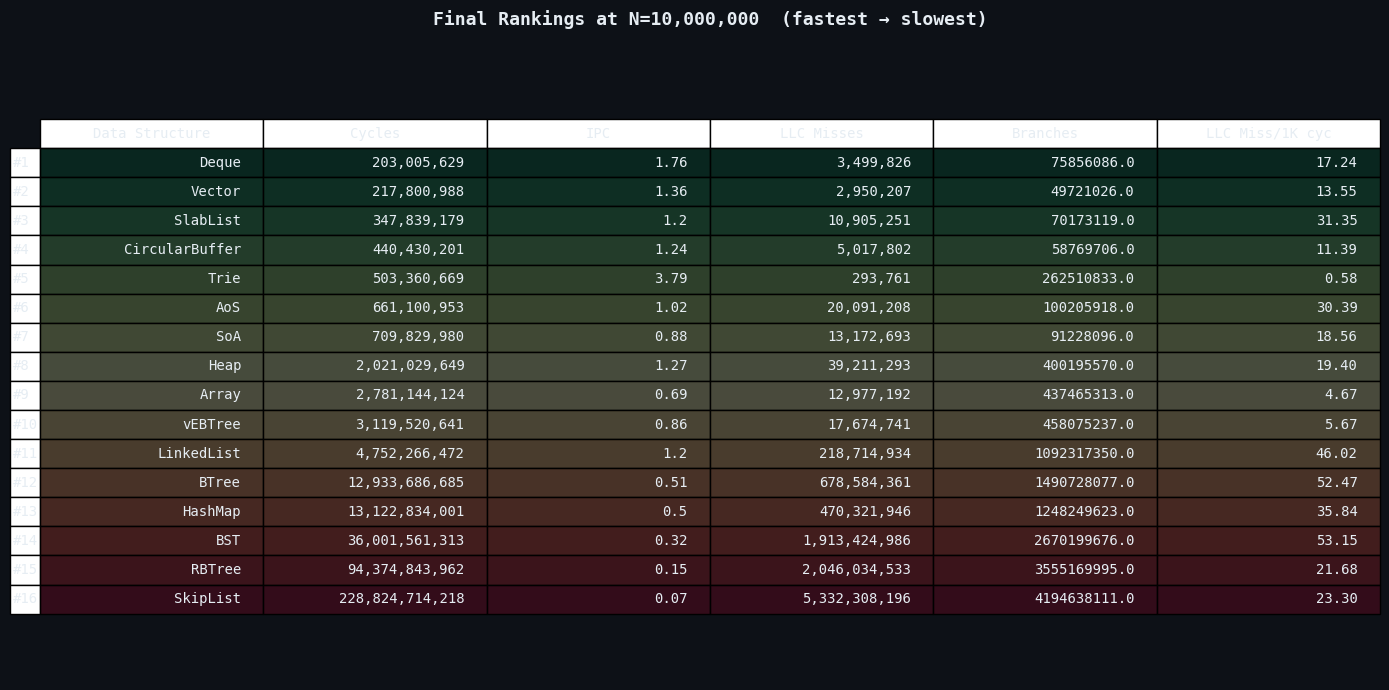

In [15]:
n_max = df['N'].max()
final = df[df['N'] == n_max][['ds','cycles','ipc','cache_misses','branches','cache_miss_rate']].copy()
final = final.sort_values('cycles').reset_index(drop=True)
final.index += 1  # rank starting at 1
final['cycles'] = final['cycles'].apply(lambda x: f'{x:,.0f}')
final['cache_misses'] = final['cache_misses'].apply(lambda x: f'{x:,.0f}' if pd.notna(x) else 'N/A')
final['cache_miss_rate'] = final['cache_miss_rate'].apply(lambda x: f'{x:.2f}' if pd.notna(x) else 'N/A')
final['ipc'] = final['ipc'].round(2)
final.columns = ['Data Structure','Cycles','IPC','LLC Misses','Branches','LLC Miss/1K cyc']

print(f'\n=== Final Rankings at N={n_max:,} (30-run mean) ===\n')
print(final.to_string())

# Visual table
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_facecolor('#0d1117'); ax.axis('off')
tbl = ax.table(cellText=final.values, colLabels=final.columns,
               rowLabels=[f'#{i}' for i in final.index],
               cellLoc='right', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)
# Colour rows by rank
n_rows = len(final)
cmap = plt.colormaps['RdYlGn'].reversed()
for i in range(n_rows):
    color = cmap(i / (n_rows - 1))
    rgba = (*color[:3], 0.25)
    for j in range(len(final.columns)):
        tbl[(i+1, j)].set_facecolor(rgba)
ax.set_title(f'Final Rankings at N={n_max:,}  (fastest → slowest)',
             fontweight='bold', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig('plot_12_rankings_table.png', dpi=150, bbox_inches='tight')
plt.show()